# Домашнее задание: Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели
## Занятие: Ансамбли моделей
### Версия fix, переделанная в соответсвии с рекомендациями преподавателя.
```
Добрый день!
EDA
Нет явной проверки дубликатов.
Утверждение, что признаки number_of_reviews, reviews_per_month, availability_365
“не несут полезной информации для модели”, слишком сильное:
слабая линейная корреляция с price не означает бесполезность признака.
В EDA нет отдельного анализа категориальных признаков по целевой переменной
до начала feature engineering.

Preprocessing / Feature Engineering
Признаки number_of_reviews, reviews_per_month, availability_365 удалены слишком рано
и только на основании корреляции с целевой переменной.
После логарифмирования minimum_nights и calculated_host_listings_count
признаки удаляются без строгого обоснования; логика “логарифм не помогает, значит удаляем” слишком слабая.
Итерация 4 методически некорректна: локальная обрезка по 95-му перцентилю
делается до train/test split, то есть порог вычисляется с использованием будущего теста.
Это утечка данных.
В итерации 4 одновременно меняются сразу несколько вещей:
локальная обрезка, новый target encoding и poly features.
Из-за этого нельзя понять, что именно дало основной прирост.

Моделирование
Не выведены лучшие гиперпараметры для RidgeCV, LassoCV, ElasticNetCV.
Нет анализа остатков. Нет визуализации y_true vs y_pred.
В выводе про “мультиколлинеарности нет” утверждение слишком категоричное; оно не доказано отдельно.
Финальный вывод по итерации 4 опирается на результат,
полученный с утечкой данных, поэтому делать из него основной вывод о качестве модели нельзя.

С уважением, Василий
```

## Часть 1. EDA

### 1. Загрузка данных

In [1]:
import pandas as pd

In [2]:
# Загружаем датасет
data = pd.read_csv('data/AB_NYC_2019.csv')

# Размерность
print(data.shape)

(48895, 16)


In [3]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
# Удаляем технические признаки
technical_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
data = data.drop(columns=technical_cols)

print(data.shape)
data.head()

(48895, 11)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### 2. Первичная проверка

In [6]:
# Пропуски по каждому столбцу
print('Пропуски по столбцам:')
print(data.isnull().sum())

Пропуски по столбцам:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [7]:
# Полные дубликаты строк
n_duplicates = data.duplicated().sum()
print(f'Полных дубликатов строк: {n_duplicates}')

if n_duplicates > 0:
    data = data.drop_duplicates()
    print(f'Удалено строк: {n_duplicates}. Новый размер: {data.shape}')
else:
    print('Дубликатов нет, удаление не требуется.')

Полных дубликатов строк: 0
Дубликатов нет, удаление не требуется.


In [8]:
# Типы признаков
print('Типы признаков:')
print(data.dtypes)

Типы признаков:
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [9]:
# Разделение признаков на числовые и категориальные
num_cols = data.select_dtypes(include='number').columns.tolist()
cat_cols = data.select_dtypes(include='str').columns.tolist()

print(f'Числовые признаки ({len(num_cols)}): {num_cols}')
print(f'Категориальные признаки ({len(cat_cols)}): {cat_cols}')

Числовые признаки (8): ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Категориальные признаки (3): ['neighbourhood_group', 'neighbourhood', 'room_type']


### 3. Анализ целевой переменной `price`

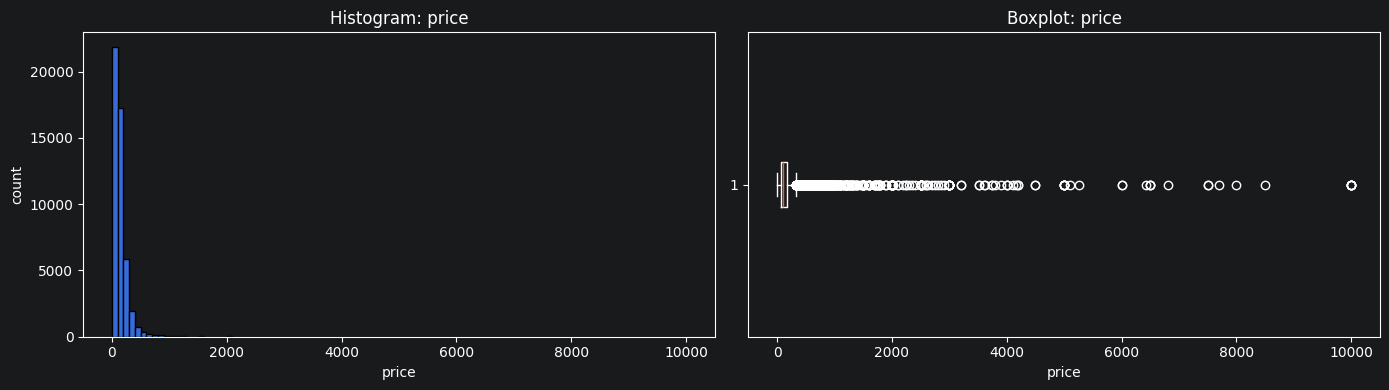

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(data['price'], bins=100, edgecolor='black')
axes[0].set_title('Histogram: price')
axes[0].set_xlabel('price')
axes[0].set_ylabel('count')

# Boxplot
axes[1].boxplot(data['price'], vert=False)
axes[1].set_title('Boxplot: price')
axes[1].set_xlabel('price')

plt.tight_layout()
plt.show()

In [11]:
# Основные статистики
stats = data['price'].agg(['mean', 'median', 'std', 'min', 'max'])
quantiles = data['price'].quantile([0.25, 0.75, 0.90, 0.95, 0.99])

print('Основные статистики:')
print(stats)
print()
print('Квантили:')
print(quantiles)


Основные статистики:
mean        152.720687
median      106.000000
std         240.154170
min           0.000000
max       10000.000000
Name: price, dtype: float64

Квантили:
0.25     69.0
0.75    175.0
0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64


In [12]:
# Проверка асимметрии и выбросов
# Skewness (коэффициент асимметрии) мера того, насколько распределение отклоняется от симметричного.
#
#   skewness = 0       симметричное распределение (как нормальное)
#   skewness > 0       правый хвост длиннее (правая асимметрия)
#   skewness < 0       левый хвост длиннее (левая асимметрия)
#
#   Практические пороги:
#   |skewness| < 0.5   примерно симметричное
#   |skewness| 0.5–1   умеренная асимметрия
#   |skewness| > 1     сильная асимметрия
#
# IQR (Interquartile Range) межквартильный размах.
#
# Это разность между 75-м и 25-м перцентилями:
#
# IQR = Q3 - Q1
# Показывает, в каком диапазоне находится средние 50% данных. Используется для определения выбросов по правилу:
#
# выброс < Q1 - 1.5 * IQR
# выброс > Q3 + 1.5 * IQR
#
# Для price:
# Q1 ~ 69 (25% объявлений дешевле этой цены)
# Q3 ~ 175 (75% объявлений дешевле этой цены)
# IQR ~ 106
# Верхняя граница ~ 175 + 1.5×106 = 334 — всё дороже считается выбросом по этому правилу

skewness = data['price'].skew()
iqr = data['price'].quantile(0.75) - data['price'].quantile(0.25)
lower_fence = data['price'].quantile(0.25) - 1.5 * iqr
upper_fence = data['price'].quantile(0.75) + 1.5 * iqr
n_outliers = ((data['price'] < lower_fence) | (data['price'] > upper_fence)).sum()

print(f'Коэффициент асимметрии (skewness): {skewness:.2f}')
print(f'IQR: {iqr:.2f}  |  Нижняя граница IQR: {lower_fence:.2f}  |  Верхняя граница IQR: {upper_fence:.2f}')
print(f'Выбросов по правилу 1.5*IQR: {n_outliers} ({n_outliers / len(data) * 100:.1f}%)')

Коэффициент асимметрии (skewness): 19.12
IQR: 106.00  |  Нижняя граница IQR: -90.00  |  Верхняя граница IQR: 334.00
Выбросов по правилу 1.5*IQR: 2972 (6.1%)


**Выводы:**
- Распределение `price` несимметрично: выражена сильная правая асимметрия (skewness > 1).
- Присутствует длинный правый хвост, есть объекты с ценой в тысячи долларов за ночь.
- Выбросов по правилу 1.5×IQR значительное количество, они сосредоточены в правом хвосте.
- Логарифмирование `price` имеет смысл, оно может сделать распределение ближе к нормальному и улучшить качество модели.

### 4. Анализ числовых признаков


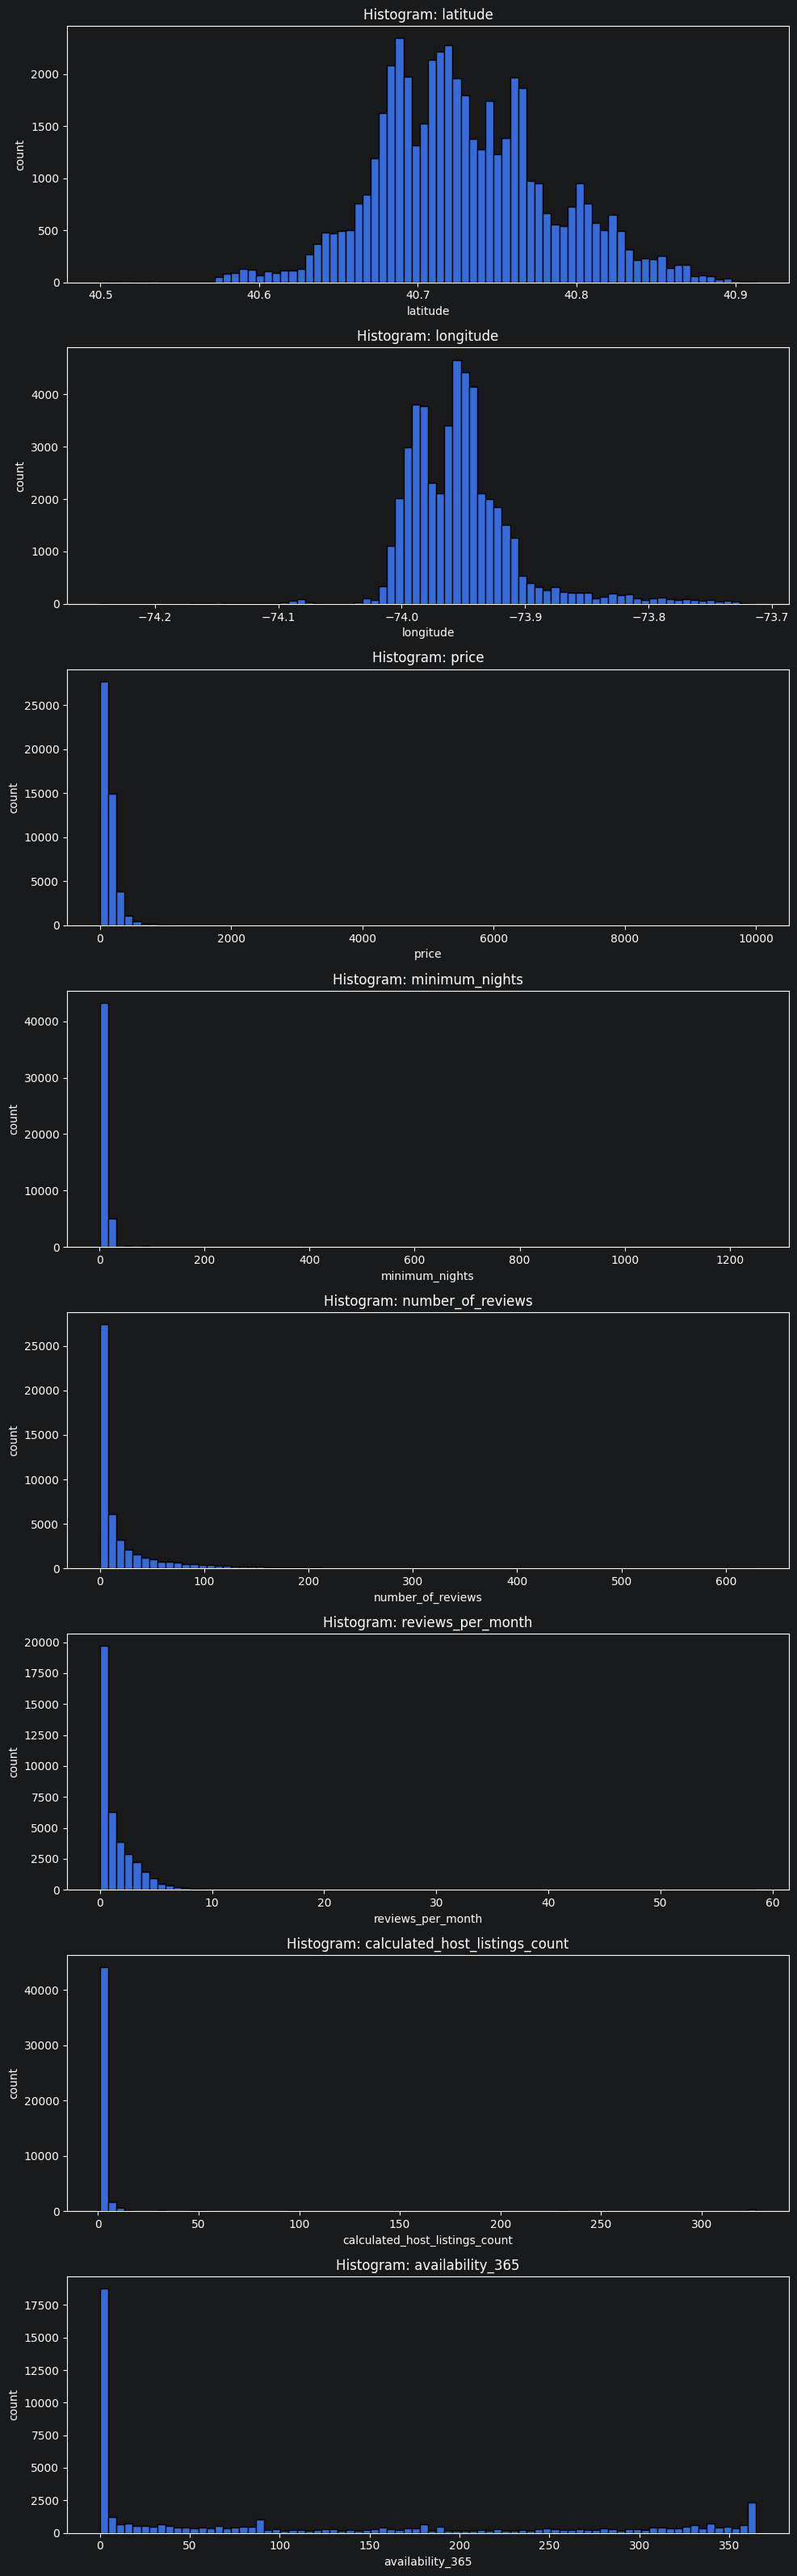

In [13]:
# Histogram для каждого числового признака
# num_cols включает price, показываем все числовые признаки
n = len(num_cols)
fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))

for i, col in enumerate(num_cols):
    axes[i].hist(data[col].dropna(), bins=80, edgecolor='black')
    axes[i].set_title(f'Histogram: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.tight_layout()
plt.show()

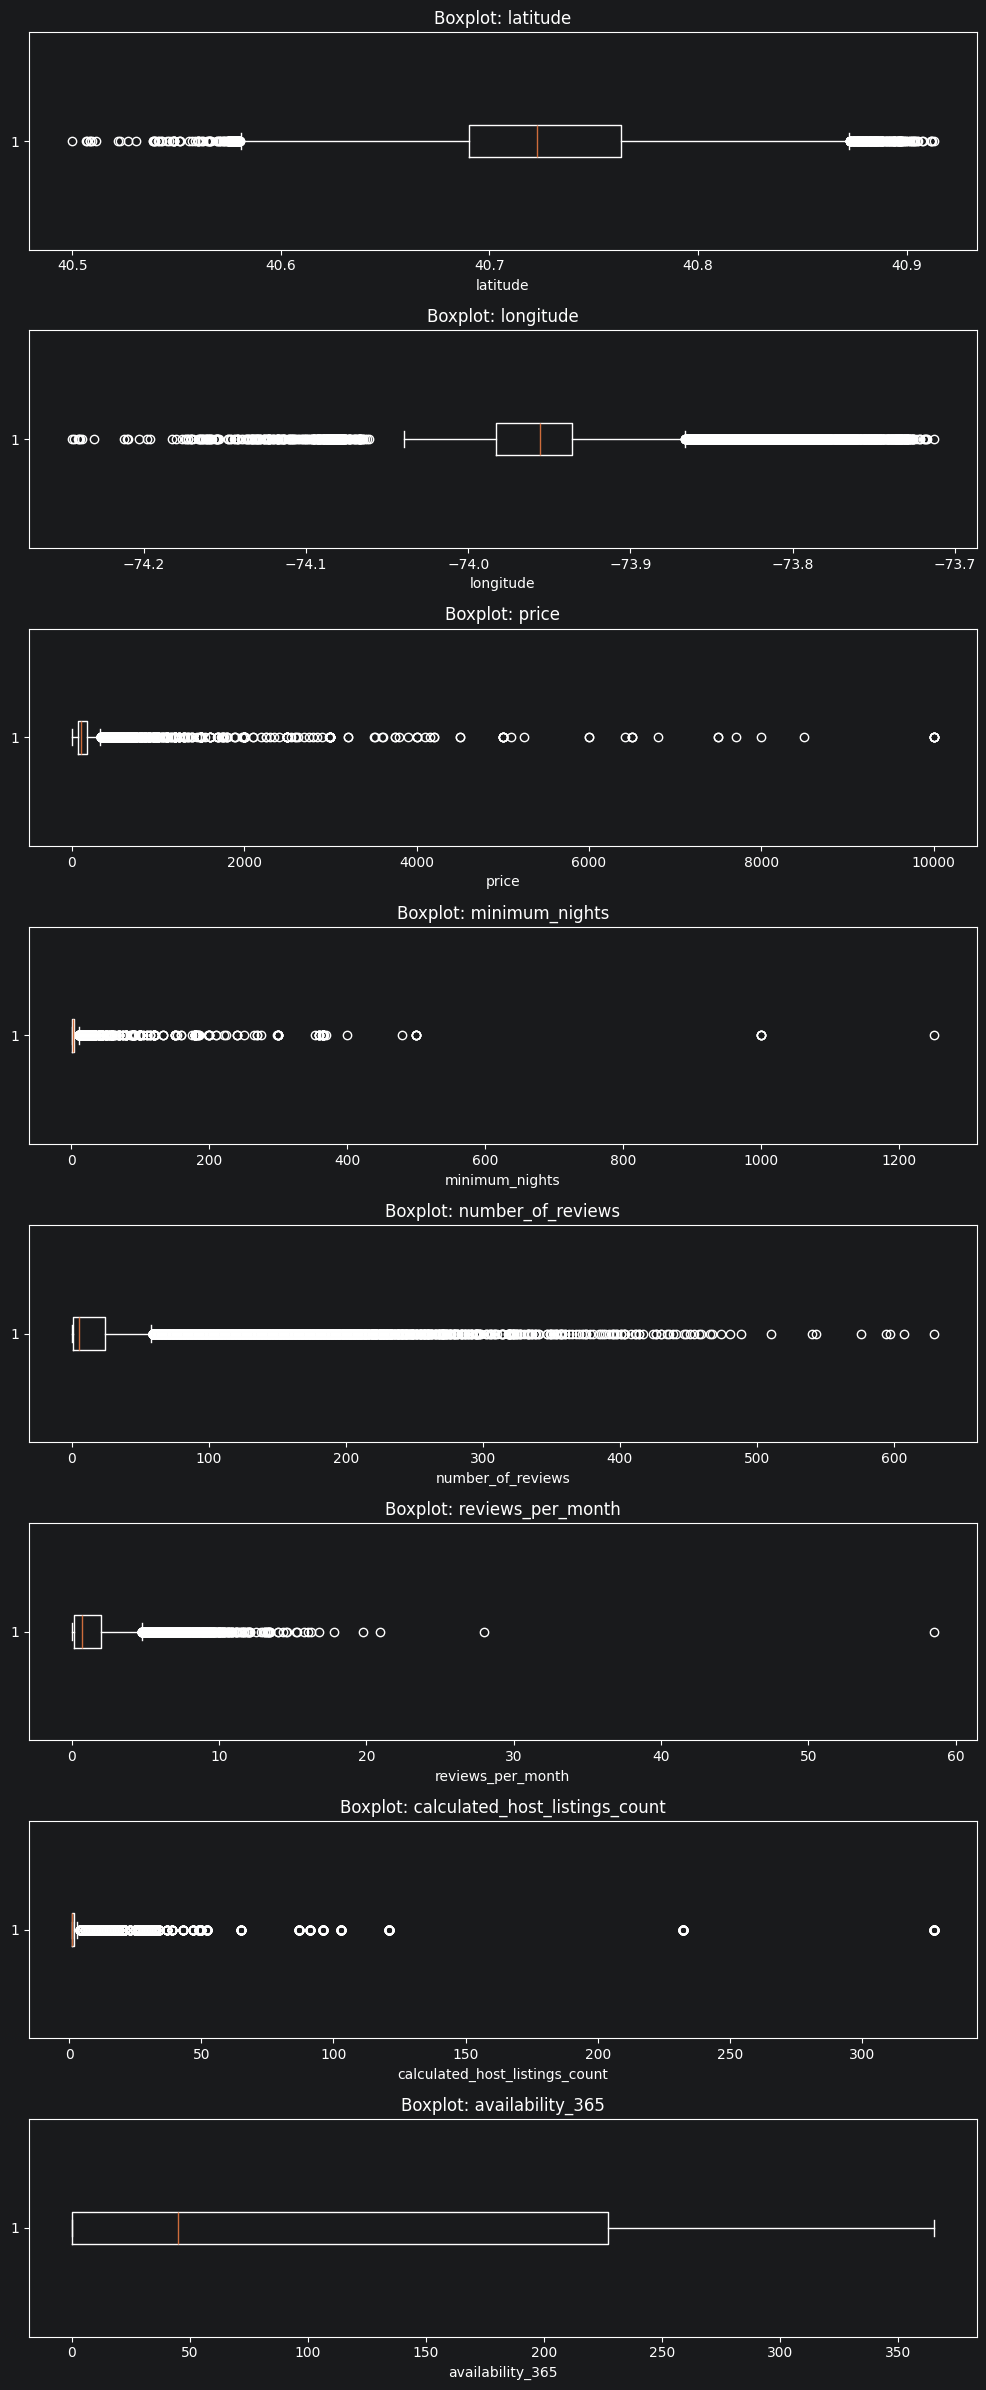

In [14]:
# Boxplot для каждого числового признака
fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))

for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col].dropna(), vert=False)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# Корреляционная матрица числовых признаков
corr_matrix = data[num_cols].corr()
print('Корреляционная матрица:')
print(corr_matrix.round(2))

Корреляционная матрица:
                                latitude  longitude  price  minimum_nights  \
latitude                            1.00       0.08   0.03            0.02   
longitude                           0.08       1.00  -0.15           -0.06   
price                               0.03      -0.15   1.00            0.04   
minimum_nights                      0.02      -0.06   0.04            1.00   
number_of_reviews                  -0.02       0.06  -0.05           -0.08   
reviews_per_month                  -0.01       0.15  -0.03           -0.12   
calculated_host_listings_count      0.02      -0.11   0.06            0.13   
availability_365                   -0.01       0.08   0.08            0.14   

                                number_of_reviews  reviews_per_month  \
latitude                                    -0.02              -0.01   
longitude                                    0.06               0.15   
price                                       -0.05        

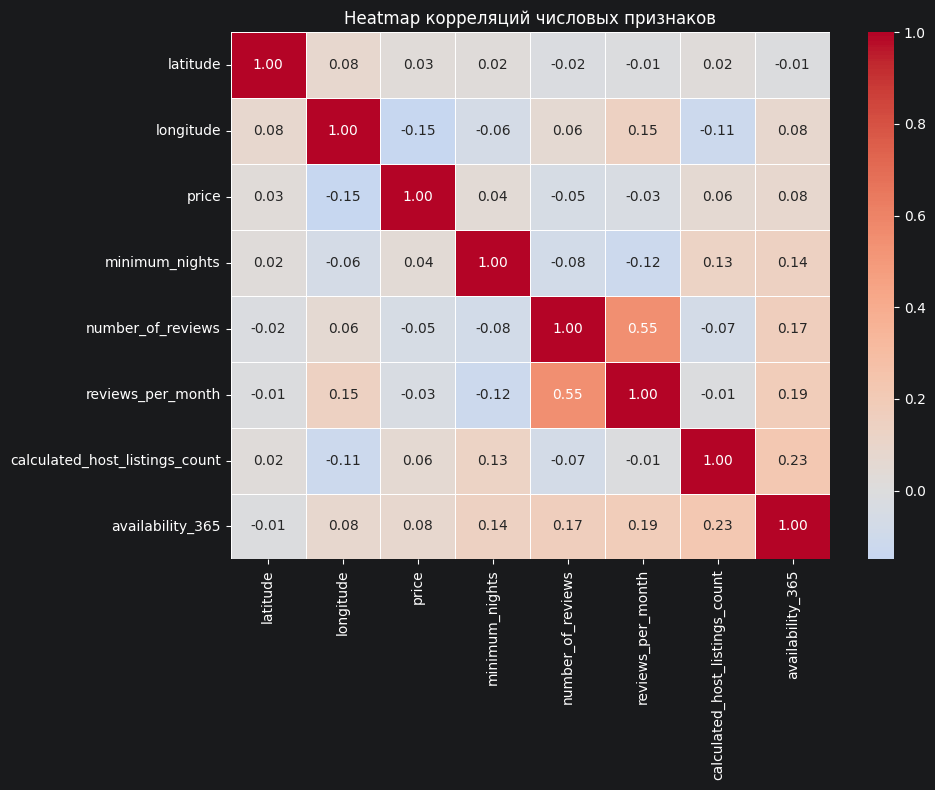

In [16]:
import seaborn as sns

# Heatmap корреляций
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Heatmap корреляций числовых признаков')
plt.tight_layout()
plt.show()

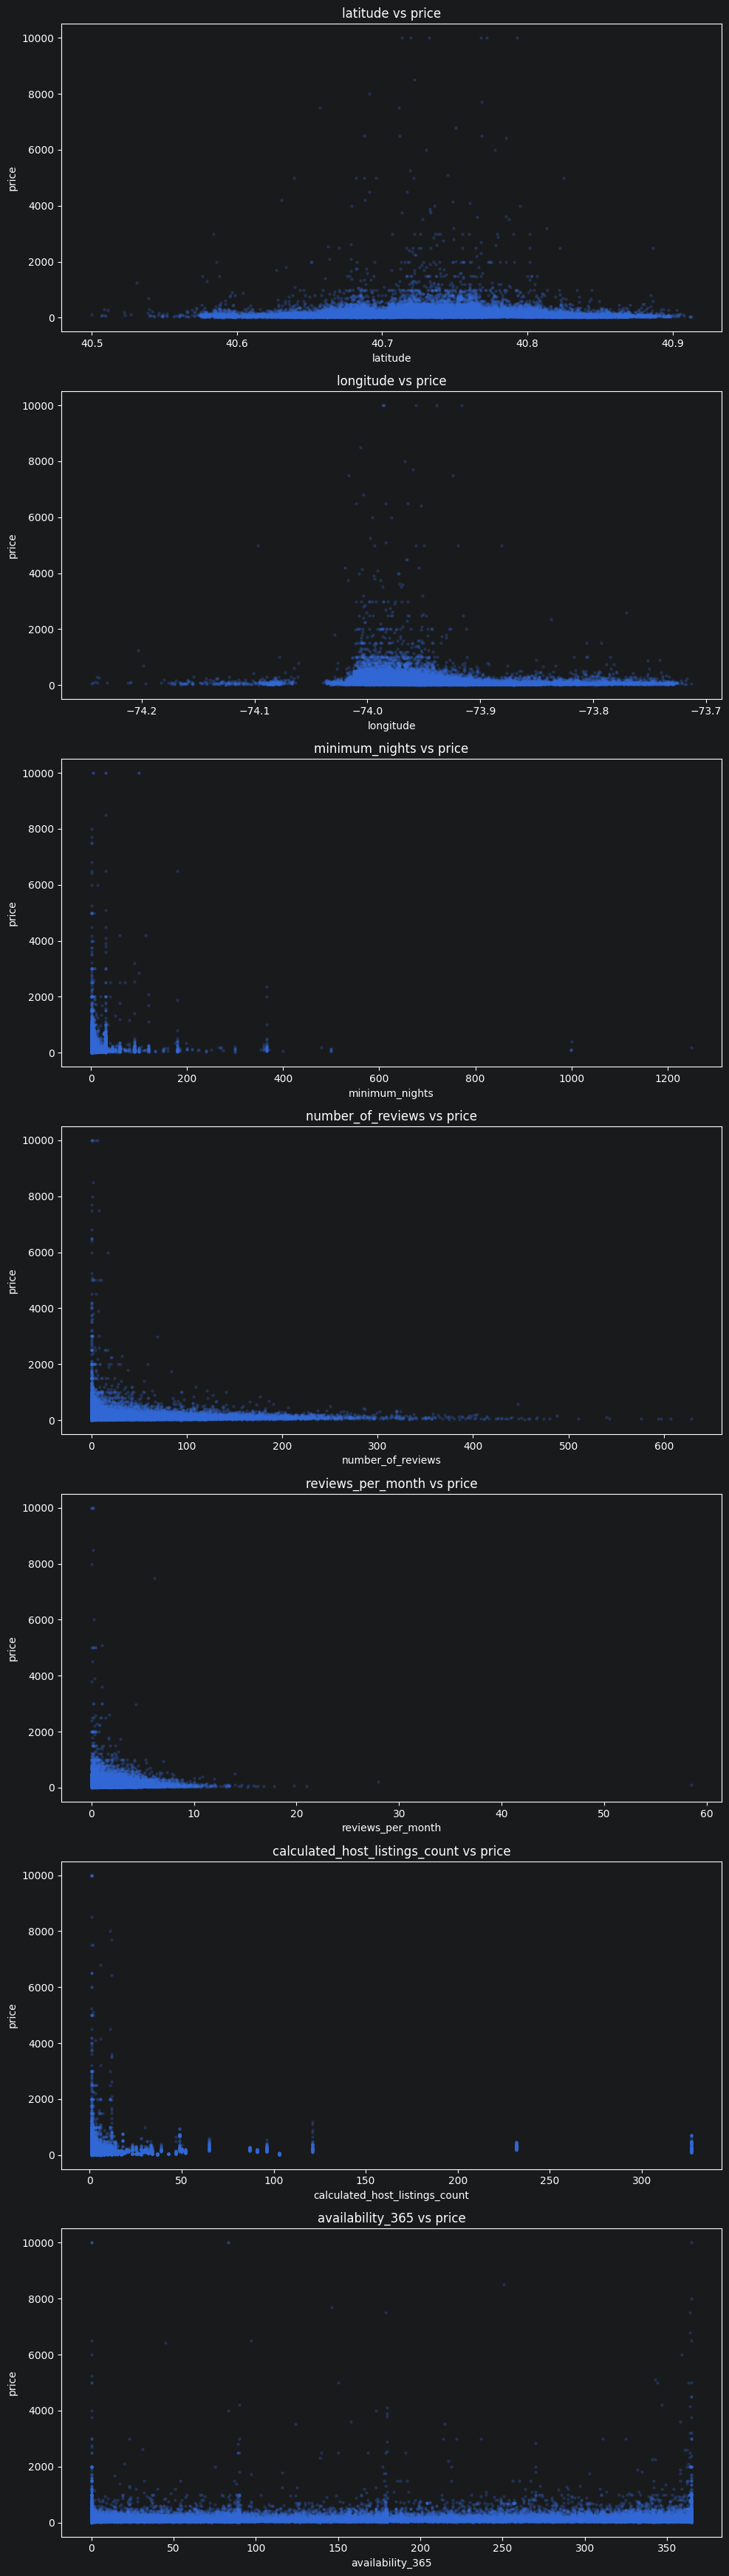

In [17]:
# Scatterplot: связь числовых признаков с price
# Берём признаки кроме самого price
scatter_cols = [col for col in num_cols if col != 'price']

fig, axes = plt.subplots(len(scatter_cols), 1, figsize=(10, 5 * len(scatter_cols)))

for i, col in enumerate(scatter_cols):
    axes[i].scatter(data[col], data['price'], alpha=0.2, s=5)
    axes[i].set_title(f'{col} vs price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')

plt.tight_layout()
plt.show()

**Выводы:**
- Большинство числовых признаков имеют правостороннюю асимметрию с выбросами.
- Корреляции числовых признаков с `price` слабые по модулю, линейная связь не выражена, что ожидаемо для ценовых данных с выбросами.
- На scatterplot с `log1p(price)` структура данных читается лучше, логарифмирование целевой переменной имеет смысл.
- Признаки не исключаются на основании одной только корреляции: слабая линейная корреляция не означает отсутствие нелинейной связи.